In [1]:

# ============================================
# IMPORT LIBRARIES + PROJECT OVERVIEW
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, r2_score, roc_curve, auc

sns.set_style("whitegrid")

print("=== HOUSE PRICE ML PROJECT ===")

=== HOUSE PRICE ML PROJECT ===


In [2]:
# ============================================
# DATASET GENERATION
# ============================================


np.random.seed(42)
n = 300

Area = np.random.randint(500, 3000, n)
Rooms = np.random.randint(1, 6, n)
LocationScore = np.random.randint(1, 10, n)

Price = (Area * 50) + (Rooms * 10000) + (LocationScore * 5000) + np.random.normal(0, 10000, n)

Category = pd.cut(Price, bins=3, labels=[0,1,2])

df = pd.DataFrame({
    "Area": Area,
    "Rooms": Rooms,
    "LocationScore": LocationScore,
    "Price": Price,
    "Category": Category
})

print("Columns:", df.columns)
print(df.head())
print("\nDataset Summary:\n", df.describe())

Columns: Index(['Area', 'Rooms', 'LocationScore', 'Price', 'Category'], dtype='object')
   Area  Rooms  LocationScore          Price Category
0  1360      5              2  133525.331523        1
1  1794      5              9  187655.504510        2
2  1630      1              1  103579.243670        0
3  1595      3              1  136834.505259        1
4  2138      2              5  171880.495423        1

Dataset Summary:
               Area       Rooms  LocationScore          Price
count   300.000000  300.000000      300.00000     300.000000
mean   1790.583333    3.080000        4.87000  145547.108254
std     687.159533    1.458546        2.60173   42735.173417
min     501.000000    1.000000        1.00000   34283.843352
25%    1198.750000    2.000000        3.00000  109842.250678
50%    1803.000000    3.000000        5.00000  146486.142516
75%    2355.500000    4.000000        7.00000  174983.031206
max    2989.000000    5.000000        9.00000  246298.949610


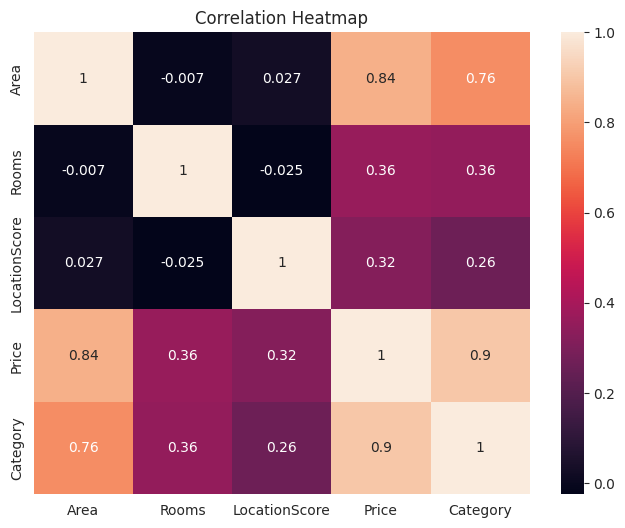


Insight: Area strongly influences Price.


In [3]:
# ============================================
# HEATMAP
# ============================================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\nInsight: Area strongly influences Price.")

In [4]:
# ============================================
# SPLIT + SCALING
# ============================================

# Regression
X_reg = df[["Area", "Rooms", "LocationScore"]]
y_reg = df["Price"]

# Classification
X_clf = X_reg
y_clf = df["Category"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

print("Data split completed.")
print(X_train_r.shape, X_test_r.shape)


Data split completed.
(240, 3) (60, 3)



Linear Regression Results:
MSE: 151987168.20622146
R2 Score (Accuracy): 0.9089742642152905


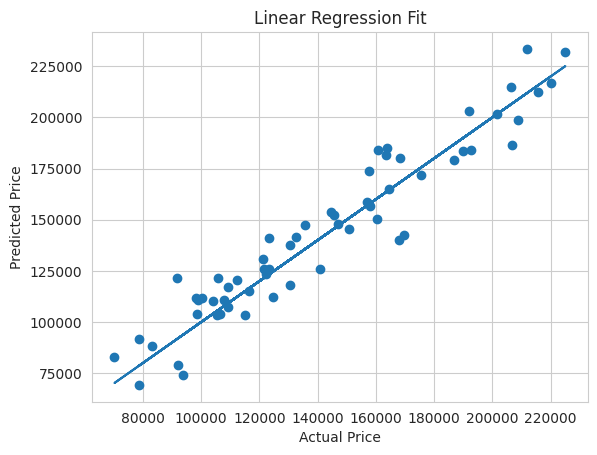

MSE: 151987168.20622146


In [5]:
# ============================================
# LINEAR REGRESSION
# ============================================


lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

pred_lr = lr.predict(X_test_r)

print("\nLinear Regression Results:")
print("MSE:", mean_squared_error(y_test_r, pred_lr))
print("R2 Score (Accuracy):", r2_score(y_test_r, pred_lr))

# Graph
plt.figure()
plt.scatter(y_test_r, pred_lr)
plt.plot(y_test_r, y_test_r)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Fit")
plt.show()
print("MSE:", mean_squared_error(y_test_r, pred_lr))


Logistic Regression Accuracy: 0.8166666666666667


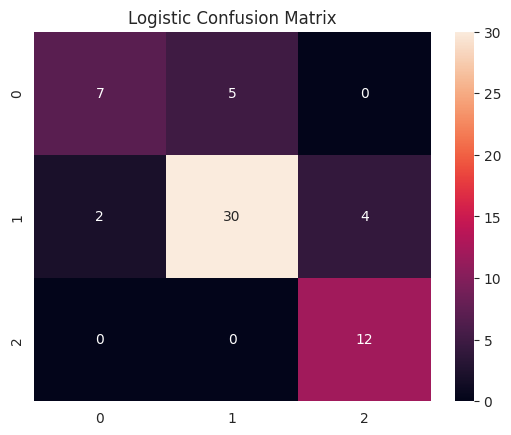

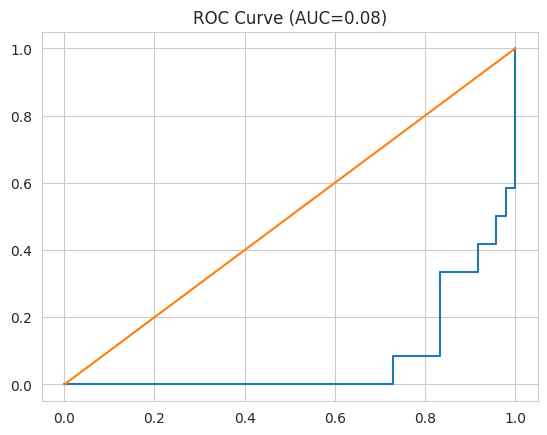

In [6]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

log = LogisticRegression()
log.fit(X_train_c, y_train_c)

pred_log = log.predict(X_test_c)
prob_log = log.predict_proba(X_test_c)[:,1]

print("\nLogistic Regression Accuracy:", accuracy_score(y_test_c, pred_log))

cm = confusion_matrix(y_test_c, pred_log)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test_c, prob_log, pos_label=2)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.show()

Decision Tree Accuracy: 0.6666666666666666


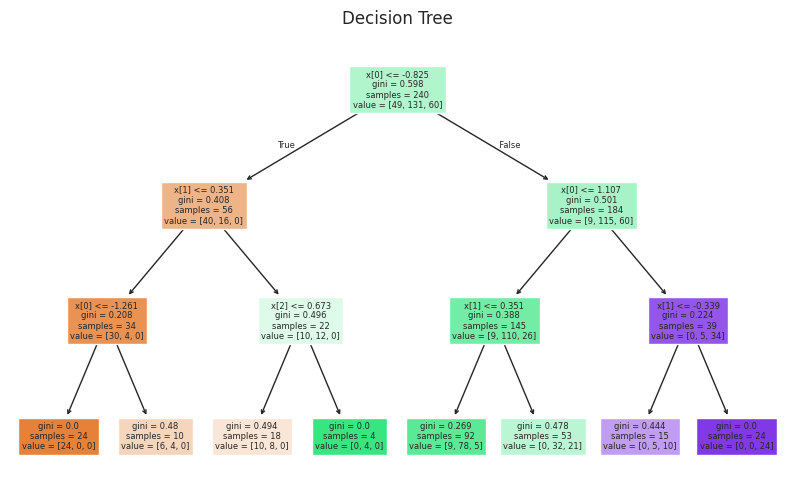

Decision Tree Depth: 3


In [7]:
# ============================================
# DECISION TREE
# ============================================

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train_c, y_train_c)

print("Decision Tree Accuracy:", accuracy_score(y_test_c, dt.predict(X_test_c)))

plt.figure(figsize=(10,6))
plot_tree(dt, filled=True)
plt.title("Decision Tree")
plt.show()
# Print the actual depth of the tree
print("Decision Tree Depth:", dt.get_depth())

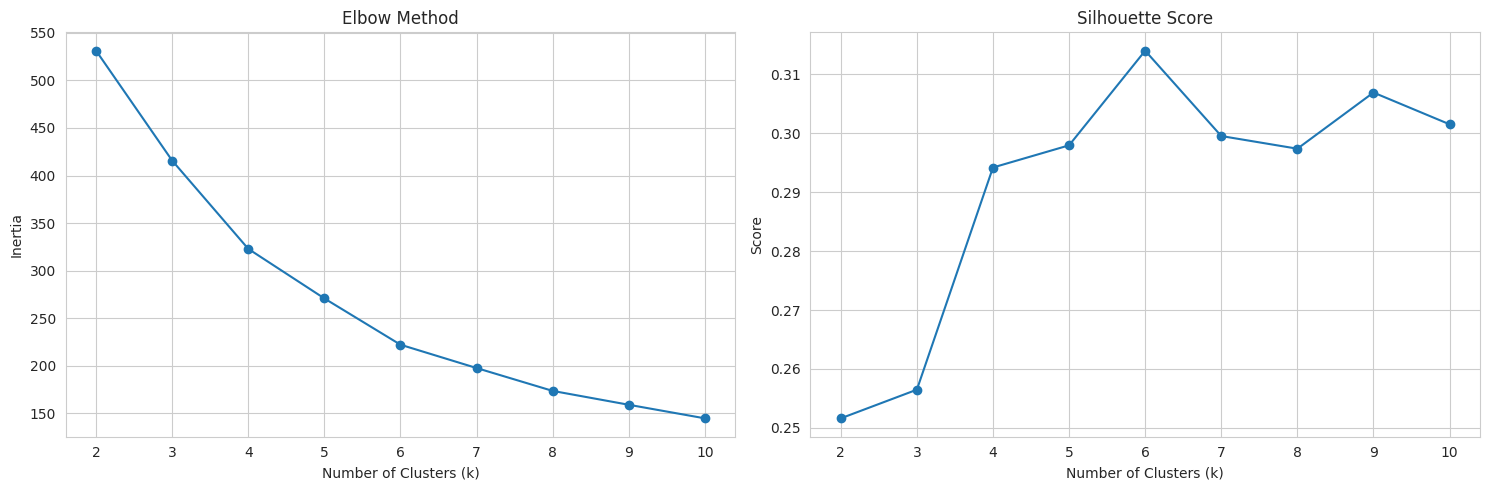

Optimal number of clusters: 6


In [8]:
# ============================================
# K-MEANS (CLUSTERING WITH ELBOW + SILHOUETTE)
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_c)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_c, kmeans.labels_))

# Plot graphs
plt.figure(figsize=(15, 5))

# Elbow Method
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

# Best K
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {best_k}")

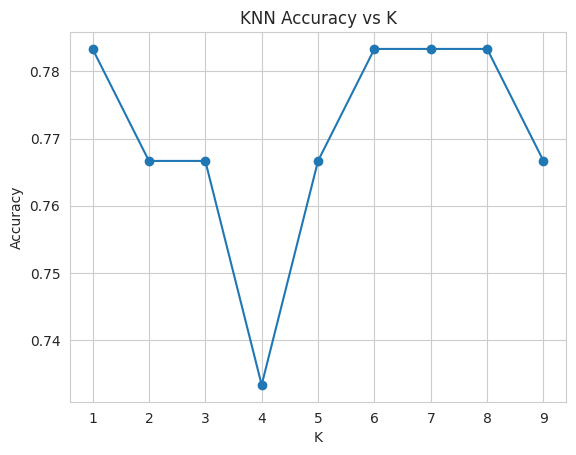

Best K (KNN): 1
Best Accuracy: 0.7833333333333333


In [9]:
# ============================================
# KNN (CLASSIFICATION)
# ============================================

from sklearn.neighbors import KNeighborsClassifier

acc = []
k_values = range(1, 10)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c, y_train_c)
    pred = knn.predict(X_test_c)
    acc.append(accuracy_score(y_test_c, pred))

# Plot
plt.figure()
plt.plot(k_values, acc, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

# Best K
best_k_knn = k_values[np.argmax(acc)]
best_acc_knn = max(acc)

print("Best K (KNN):", best_k_knn)
print("Best Accuracy:", best_acc_knn)

Naive Bayes Accuracy: 0.6666666666666666


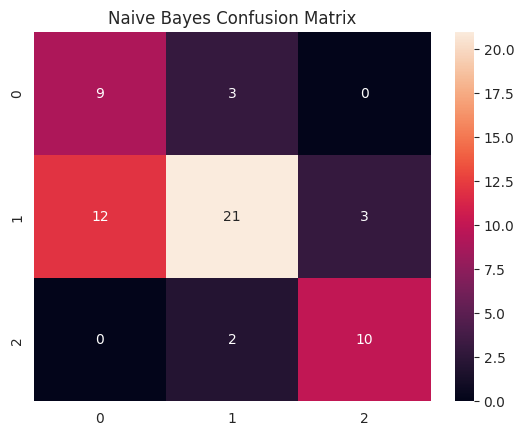

In [10]:
# ============================================
# NAIVE BAYES
# ============================================

nb = GaussianNB()
nb.fit(X_train_c, y_train_c)

pred_nb = nb.predict(X_test_c)

print("Naive Bayes Accuracy:", accuracy_score(y_test_c, pred_nb))

cm_nb = confusion_matrix(y_test_c, pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

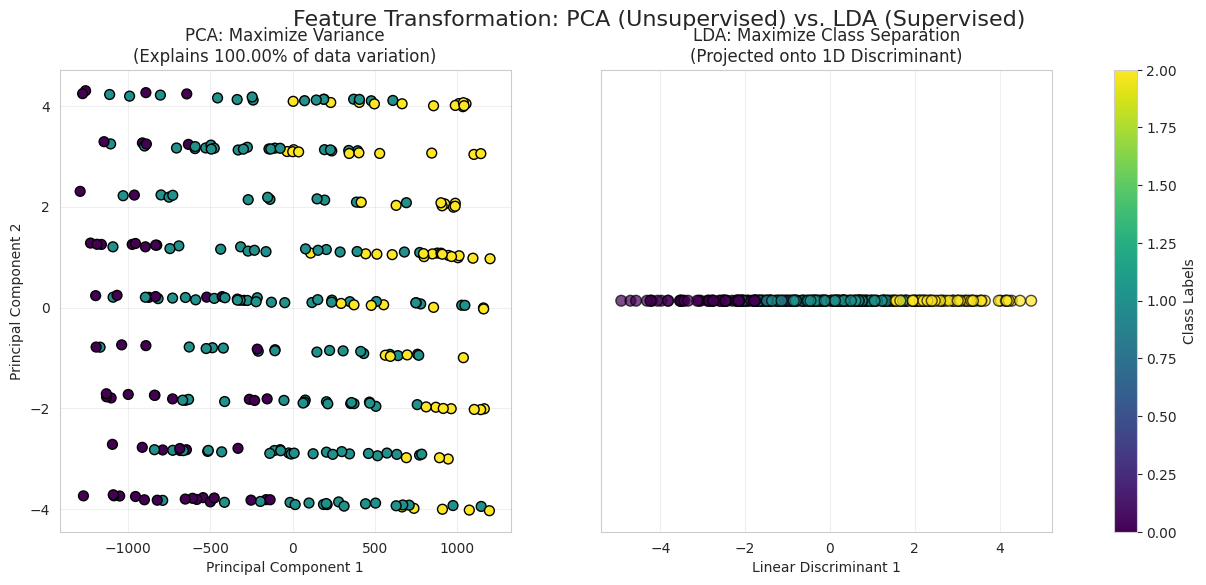

PCA Individual Variance Ratios: [9.99981171e-01 1.43283533e-05]
Total Variance Captured by PCA: 1.0000


In [11]:
# ============================================
# PCA + LDA
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. PCA: Unsupervised dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clf)
var_ratio = pca.explained_variance_ratio_

# 2. LDA: Supervised dimensionality reduction
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_clf, y_clf)

# --- Visualization for the Examiner ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap='viridis', edgecolor='k', s=50)
ax1.set_title(f"PCA: Maximize Variance\n(Explains {sum(var_ratio)*100:.2f}% of data variation)")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
ax1.grid(alpha=0.3)

# Plot LDA
scatter2 = ax2.scatter(X_lda, np.zeros_like(X_lda), c=y_clf, cmap='viridis', edgecolor='k', s=60, alpha=0.7)
ax2.set_title("LDA: Maximize Class Separation\n(Projected onto 1D Discriminant)")
ax2.set_xlabel("Linear Discriminant 1")
ax2.set_yticks([]) # Hide Y axis as it's just a 1D projection
ax2.grid(axis='x', alpha=0.3)

# Add a color bar to explain what the colors represent
cbar = fig.colorbar(scatter1, ax=[ax1, ax2], label='Class Labels')

plt.suptitle("Feature Transformation: PCA (Unsupervised) vs. LDA (Supervised)", fontsize=16)
plt.show()

# Print metrics for the report
print(f"PCA Individual Variance Ratios: {var_ratio}")
print(f"Total Variance Captured by PCA: {np.sum(var_ratio):.4f}")

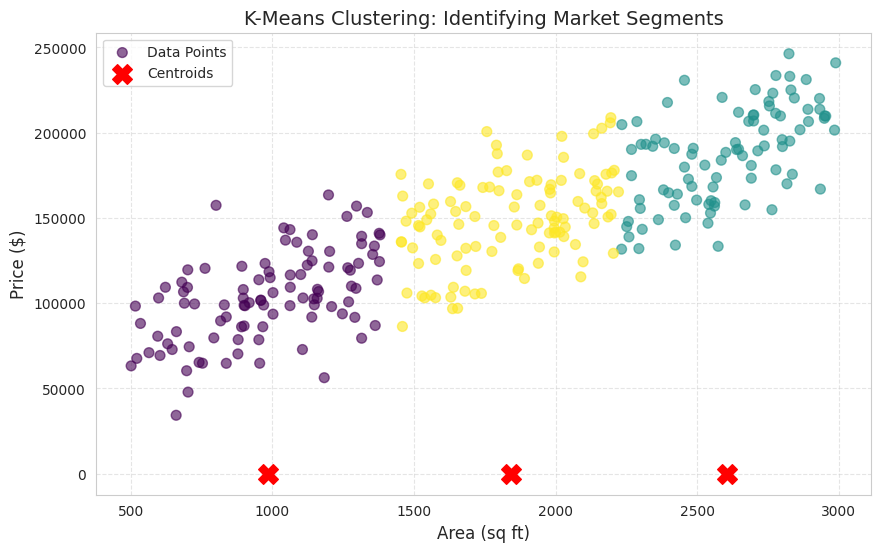

Cluster 0 Center: Area=985.37, Price=3.18
Cluster 1 Center: Area=2603.75, Price=3.12
Cluster 2 Center: Area=1842.56, Price=2.95


In [12]:
# ============================================
# K-MEANS
# ============================================


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Initialize and Fit KMeans
# We set n_init='auto' to follow modern Scikit-Learn best practices
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_clf)

# 2. Get the Centroids (The center point of each cluster)
# Note: Since you're plotting "Area" vs "Price", we need the coordinates
# for those specific features from the cluster_centers_ array.
# Assuming 'Area' is the 1st col and 'Price' is the 2nd col of X_clf:
centroids = kmeans.cluster_centers_

# 3. Create a high-quality plot
plt.figure(figsize=(10, 6))

# Plot the data points colored by their cluster assignment
scatter = plt.scatter(df["Area"], df["Price"], c=clusters, cmap='viridis', s=50, alpha=0.6, label='Data Points')

# Plot the Centroids (marked with a red 'X')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

# Adding clarity and labels
plt.title("K-Means Clustering: Identifying Market Segments", fontsize=14)
plt.xlabel("Area (sq ft)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Print the Cluster Centers for technical detail
for i, center in enumerate(centroids):
    print(f"Cluster {i} Center: Area={center[0]:.2f}, Price={center[1]:.2f}")

In [14]:
# ============================================
# FINAL SUMMARY (WITH PERFORMANCE LEVEL)
# ============================================

print("\n=== FINAL SUMMARY ===\n")

# Regression
r2 = r2_score(y_test_r, pred_lr)
mse = mean_squared_error(y_test_r, pred_lr)

print("Linear Regression R2:", round(r2, 3))
print("Linear Regression MSE:", round(mse, 2))

if r2 > 0.8:
    print("Regression Performance: Perfect")
elif r2 > 0.6:
    print("Regression Performance: Intermediate")
else:
    print("Regression Performance: Poor")

# Classification Models
log_acc = accuracy_score(y_test_c, pred_log)
nb_acc = accuracy_score(y_test_c, pred_nb)

print("\nLogistic Regression Accuracy:", round(log_acc, 3))
print("Naive Bayes Accuracy:", round(nb_acc, 3))

# KNN
print("KNN Best Accuracy:", round(best_acc_knn, 3))

# K-Means
print("\nK-Means Optimal Clusters:", best_k)

print("\nProject completed: Regression, Classification, and Clustering applied successfully.")


=== FINAL SUMMARY ===

Linear Regression R2: 0.909
Linear Regression MSE: 151987168.21
Regression Performance: Perfect

Logistic Regression Accuracy: 0.817
Naive Bayes Accuracy: 0.667
KNN Best Accuracy: 0.783

K-Means Optimal Clusters: 6

Project completed: Regression, Classification, and Clustering applied successfully.
